In [ ]:
!pip install maticalgos

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.5/254.5 kB 10.3 MB/s eta 0:00:00
  Created wheel for maticalgos: filename=maticalgos-0.70-py3-none-any.whl size=2505 sha256=7f97ec4611ea17aaa825ff675bb3fcf2f4ed285bdf225516b6ac8f550847c663
  Stored in directory: /root/.cache/pip/wheels/96/a0/b2/a124839415aa858d6e0ac1e991327070e2070b96143dd16574
Successfully built maticalgos


## Black Scholes Options Pricing Model

In [ ]:
from scipy.stats import norm
import pandas as pd
import numpy as np
from maticalgos.historical import historical
import datetime
import matplotlib.pyplot as plt
import yaml

#### Parameters of the Model

K: Strike price
<br>
T: Time to maturity (in years)
<br>
r: Risk-free interest rate
<br>
σ: Volatility
<br>
N(x): Cumulative distribution function of the standard normal distribution

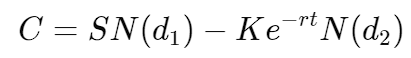
<br>
C = Call option price

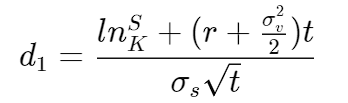

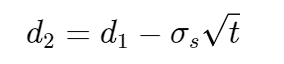

#### Function for PUT and CALL options

In [ ]:
N = norm.cdf
# Call option
def BS_CALL(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * N(d1) - K * np.exp(-r*T)* N(d2)
# Put Option
def BS_PUT(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma* np.sqrt(T)
    return K*np.exp(-r*T)*N(-d2) - S*N(-d1)

Downloading data from MaticAlgos

This is the only source for intraday options data of NSE Indices

In [ ]:
with open('cred.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [ ]:
ma = historical(config['email'])
ma.login(config['password'])  #Logging in to MaticAlgos

In [ ]:
ticker = "nifty"

In [ ]:
data = ma.get_data(ticker, datetime.date(2024,10,1))

In [ ]:
data.head()

,close,date,high,low,oi,open,symbol,time,volume
0,0.4,2024-10-01,0.75,0.4,7385350.0,0.45,NIFTY03OCT2423050PE,09:15:00,164628
1,0.45,2024-10-01,0.45,0.4,7385350.0,0.4,NIFTY03OCT2423050PE,09:16:00,12100
2,0.45,2024-10-01,0.45,0.4,7385350.0,0.45,NIFTY03OCT2423050PE,09:17:00,17525
3,0.4,2024-10-01,0.45,0.4,7384100.0,0.45,NIFTY03OCT2423050PE,09:18:00,36050
4,0.45,2024-10-01,0.45,0.4,7384100.0,0.4,NIFTY03OCT2423050PE,09:19:00,43150


In [ ]:
data.to_csv('data.csv')

Data segregation or merger

filtering out the spot (index) data from the downloaded data for calcualtions using Put and Call function of Black Scholes Model

In [ ]:
spot_data = data[data["symbol"] == ticker]
spot_data = spot_data.reset_index(drop=True)

In [ ]:
data = pd.read_csv('data.csv')
spot_data = data[data['symbol'] == 'NIFTY']

In [ ]:
mean_value = spot_data['close'].describe()['mean']

In [ ]:
mean_strike_price = round(mean_value, -2)
mean_strike_price = int(mean_strike_price)

In [ ]:
spot_data.head()

,Unnamed: 0,close,date,high,low,oi,open,symbol,time,volume
43897,43897,25895.60,2024-10-01,25898.1,25788.05,NaN,25788.45,NIFTY,09:15:00,0
43898,43898,25898.30,2024-10-01,25900.0,25878.95,NaN,25893.35,NIFTY,09:16:00,0
43899,43899,25898.25,2024-10-01,25905.2,25895.65,NaN,25899.50,NIFTY,09:17:00,0
43900,43900,25888.40,2024-10-01,25907.6,25888.35,NaN,25898.80,NIFTY,09:18:00,0
43901,43901,25897.35,2024-10-01,25900.5,25887.20,NaN,25888.75,NIFTY,09:19:00,0


In [ ]:
def days_to_years(days):
    return days / 365

### Effect of Underlying Price on Option Value

In [ ]:
K1 = mean_strike_price
K2 = mean_strike_price - 100
K3 = mean_strike_price + 100
T = days_to_years(6)
r = 0.07
sigma = 0.14

In [ ]:
results_call_K1 = [BS_CALL(S,K1,T,r,sigma) for S in spot_data['close']]
results_call_K2 = [BS_CALL(S,K2,T,r,sigma) for S in spot_data['close']]
results_call_K3 = [BS_CALL(S,K3,T,r,sigma) for S in spot_data['close']]

results_put_K1 = [BS_PUT(S,K1,T,r,sigma) for S in spot_data['close']]
results_put_K2 = [BS_PUT(S,K2,T,r,sigma) for S in spot_data['close']]
results_put_K3 = [BS_PUT(S,K3,T,r,sigma) for S in spot_data['close']]

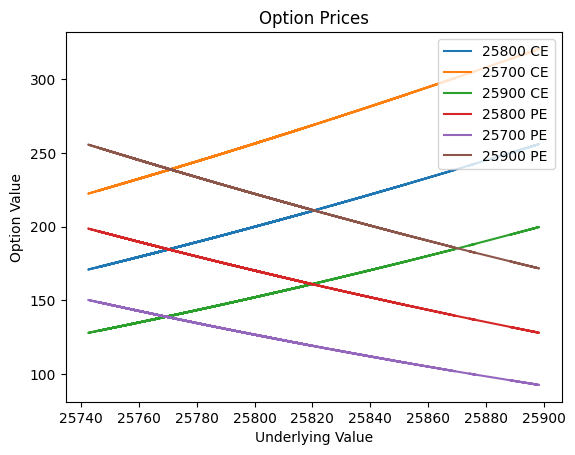

In [ ]:
# x_values = range(len(results_call_K1))
x_values = spot_data['close']
plt.plot(x_values,results_call_K1,label=f"{K1} CE")
plt.plot(x_values,results_call_K2,label=f"{K2} CE")
plt.plot(x_values,results_call_K3,label=f"{K3} CE")

plt.plot(x_values,results_put_K1,label=f"{K1} PE")
plt.plot(x_values,results_put_K2,label=f"{K2} PE")
plt.plot(x_values,results_put_K3,label=f"{K3} PE")

plt.title('Option Prices')
plt.xlabel('Underlying Value')
plt.ylabel('Option Value')
plt.legend()

### Effect of Time on Options Prices

In [ ]:
K11 = mean_strike_price
K22 = mean_strike_price + 300
T = [days_to_years(6),days_to_years(5),days_to_years(4),days_to_years(3),days_to_years(2),days_to_years(1)]
Time = [6,5,4,3,2,1 ]
r = 0.07
sigma = 0.14
S = 26000

In [ ]:
values_call_K1 = [BS_CALL(S,K11,t,r,sigma) for t in T]
values_call_K2 = [BS_CALL(S,K22,t,r,sigma) for t in T]
values_put_K1 = [BS_PUT(S,K11,t,r,sigma) for t in T]
values_put_K2 = [BS_PUT(S,K22,t,r,sigma) for t in T]

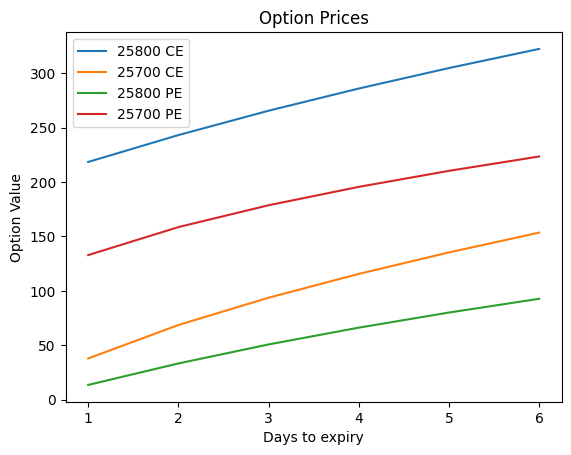

In [ ]:
plt.plot(Time,values_call_K1,label=f"{K1} CE")
plt.plot(Time,values_call_K2,label=f"{K2} CE")

plt.plot(Time,values_put_K1,label=f"{K1} PE")
plt.plot(Time,values_put_K2,label=f"{K2} PE")

plt.title('Option Prices')
plt.xlabel('Days to expiry')
plt.ylabel('Option Value')
plt.legend()